# Đánh giá hệ thống RAG HUSC

Phần đánh giá tập trung vào các chỉ số cốt lõi:

- **Retrieval:** Hit@3, MRR
- **Answer:** Keyword Accuracy (câu trả lời có chứa đúng ý chính không)
- **OOD:** Accuracy (từ chối đúng câu hỏi ngoài phạm vi)
- **Hiệu năng:** thời gian phản hồi trung bình



In [1]:
from pathlib import Path
import sys, time, unicodedata, json

import pandas as pd
import matplotlib.pyplot as plt

# Tìm thư mục gốc dự án (chứa src/rag_pipeline.py)
current = Path.cwd().resolve()
PROJECT_ROOT = next(
    p for p in [current, *current.parents, current / "Project_LLM"]
    if (p / "src" / "rag_pipeline.py").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
REPORT_DIR = PROJECT_ROOT / "data" / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(SRC_DIR))

from rag_pipeline import ask, init_rag_system

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Project_LLM


## 1. Bộ câu hỏi kiểm thử

Mỗi câu In-domain có `document`/`article` kỳ vọng để chấm retrieval và `keywords` để chấm câu trả lời. Câu OOD được tính đúng khi hệ thống **không trả về nguồn nào**.


In [2]:
TEST_CASES = [
    {"question": "Tín chỉ là gì?", "answerable": True,
     "document": "673/QĐ-ĐHKH", "article": "Điều 6",
     "keywords": ["đơn vị quy chuẩn", "khối lượng học tập"]},
    {"question": "Sinh viên bị buộc thôi học trong những trường hợp nào?", "answerable": True,
     "document": "673/QĐ-ĐHKH", "article": "Điều 20",
     "keywords": ["3 lần cảnh báo", "thời gian tối đa", "thi hộ"]},
    {"question": "Sinh viên thi hộ lần đầu bị xử lý như thế nào?", "answerable": True,
     "document": "673/QĐ-ĐHKH", "article": "Điều 44",
     "keywords": ["đình chỉ học tập", "01 năm"]},
    {"question": "Thi tự luận học phần 3 tín chỉ kéo dài bao lâu?", "answerable": True,
     "document": "673/QĐ-ĐHKH", "article": "Điều 32",
     "keywords": ["120 phút"]},
    {"question": "Một ngày có bao nhiêu tiết học?", "answerable": True,
     "document": "1453/QĐ-ĐHKH", "article": None,
     "keywords": ["13 tiết"]},
    {"question": "Tiết 13 học từ mấy giờ đến mấy giờ?", "answerable": True,
     "document": "1453/QĐ-ĐHKH", "article": None,
     "keywords": ["19 giờ 50", "20 giờ 40"]},
    {"question": "Xếp loại xuất sắc cần bao nhiêu điểm?", "answerable": True,
     "document": "673/QĐ-ĐHKH", "article": None,
     "keywords": ["3,60", "4,00"]},
    {"question": "Trường có bán đồ ăn trưa cho sinh viên không?", "answerable": False},
    {"question": "Messi ghi bao nhiêu bàn thắng?", "answerable": False},
    {"question": "Thủ đô của Việt Nam là gì?", "answerable": False},
]

len(TEST_CASES)

10

## 2. Hàm chấm điểm (giống logic `src/evaluate.py`, viết gọn lại)

In [3]:
def normalize(text):
    text = unicodedata.normalize("NFC", str(text)).lower()
    return " ".join(text.split())


def find_rank(sources, document, article):
    # Thu hang cua nguon dung trong danh sach ket qua tra ve (1-based).
    for rank, source in enumerate(sources, start=1):
        if document and source.get("document_number") != document:
            continue
        if article and source.get("article") != article:
            continue
        return rank
    return None


def keyword_accuracy(answer, keywords):
    answer = normalize(answer)
    if not keywords:
        return True
    return all(normalize(k) in answer for k in keywords)

## 3. Chạy đánh giá

In [4]:
client, model_name, resources = init_rag_system()

# Chuỗi từ chối chuẩn của hệ thống
REFUSAL_PHRASES = [
    "tài liệu hiện tại không đề cập",
    "không có thông tin",
    "không tìm thấy",
    "ngoài phạm vi",
    "không quy định"
]

rows = []
for i, tc in enumerate(TEST_CASES, start=1):
    start = time.time()
    result = ask(tc["question"], client, model_name, resources, top_k=3)
    elapsed = time.time() - start

    answer = result.get("answer", "")
    sources = result.get("sources", [])

    if tc["answerable"]:
        rank = find_rank(sources, tc.get("document"), tc.get("article"))
        retrieval_ok = rank is not None
        answer_ok = keyword_accuracy(answer, tc.get("keywords", []))
    else:
        rank = None
        # OOD: Kiểm tra xem Gemini có chứa câu từ chối chuẩn hay không
        norm_answer = normalize(answer)
        is_refused = any(normalize(phrase) in norm_answer for phrase in REFUSAL_PHRASES)
        
        retrieval_ok = is_refused
        answer_ok = is_refused

    rows.append({
        "question": tc["question"],
        "type": "In-domain" if tc["answerable"] else "OOD",
        "rank": rank,
        "retrieval_ok": retrieval_ok,
        "answer_ok": answer_ok,
        "time_s": round(elapsed, 2),
    })
    print(f"[{i}/{len(TEST_CASES)}] {'OK' if answer_ok else 'FAIL'} - {tc['question']} ({elapsed:.1f}s)")

df = pd.DataFrame(rows)
df

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[1/10] OK - Tín chỉ là gì? (31.4s)
[2/10] OK - Sinh viên bị buộc thôi học trong những trường hợp nào? (22.1s)
[3/10] OK - Sinh viên thi hộ lần đầu bị xử lý như thế nào? (31.1s)
[4/10] OK - Thi tự luận học phần 3 tín chỉ kéo dài bao lâu? (28.8s)
[5/10] OK - Một ngày có bao nhiêu tiết học? (27.3s)
[6/10] OK - Tiết 13 học từ mấy giờ đến mấy giờ? (26.3s)
[7/10] OK - Xếp loại xuất sắc cần bao nhiêu điểm? (25.5s)
[8/10] OK - Trường có bán đồ ăn trưa cho sinh viên không? (25.7s)
[9/10] OK - Messi ghi bao nhiêu bàn thắng? (23.6s)
[10/10] OK - Thủ đô của Việt Nam là gì? (23.1s)


,question,type,rank,retrieval_ok,answer_ok,time_s
0,Tín chỉ là gì?,In-domain,1.0,True,True,31.40
1,Sinh viên bị buộc thôi học trong những trường ...,In-domain,2.0,True,True,22.05
2,Sinh viên thi hộ lần đầu bị xử lý như thế nào?,In-domain,1.0,True,True,31.11
3,Thi tự luận học phần 3 tín chỉ kéo dài bao lâu?,In-domain,1.0,True,True,28.77
4,Một ngày có bao nhiêu tiết học?,In-domain,1.0,True,True,27.26
5,Tiết 13 học từ mấy giờ đến mấy giờ?,In-domain,1.0,True,True,26.33
6,Xếp loại xuất sắc cần bao nhiêu điểm?,In-domain,1.0,True,True,25.49
7,Trường có bán đồ ăn trưa cho sinh viên không?,OOD,NaN,True,True,25.68
8,Messi ghi bao nhiêu bàn thắng?,OOD,NaN,True,True,23.59
9,Thủ đô của Việt Nam là gì?,OOD,NaN,True,True,23.05


In [5]:
# Chạy thử trực tiếp 3 câu OOD để xem nguyên văn câu trả lời của Gemini
for tc in [t for t in TEST_CASES if not t["answerable"]]:
    res = ask(tc["question"], client, model_name, resources, top_k=3)
    print("=" * 60)
    print("Câu hỏi:", tc["question"])
    print("Gemini trả lời:\n", res["answer"])

Câu hỏi: Trường có bán đồ ăn trưa cho sinh viên không?
Gemini trả lời:
 Tài liệu hiện tại không đề cập chi tiết về vấn đề này.
Câu hỏi: Messi ghi bao nhiêu bàn thắng?
Gemini trả lời:
 Tài liệu hiện tại không đề cập chi tiết về vấn đề này.
Câu hỏi: Thủ đô của Việt Nam là gì?
Gemini trả lời:
 Tài liệu hiện tại không đề cập chi tiết về vấn đề này.


## 4. Tổng hợp chỉ số cốt lõi

In [6]:
in_domain = df[df["type"] == "In-domain"]
ood = df[df["type"] == "OOD"]

summary = {
    "Retrieval Hit@3": in_domain["retrieval_ok"].mean(),
    "MRR": (1 / in_domain["rank"]).fillna(0).mean(),
    "Answer Keyword Accuracy": in_domain["answer_ok"].mean(),
    "OOD Accuracy": ood["answer_ok"].mean(),
    "Mean Latency (s)": df["time_s"].mean(),
}

print(f"OOD từ chối đúng: {int(ood['answer_ok'].sum())}/{len(ood)}")

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
summary_df.round(3)

OOD từ chối đúng: 3/3


,Metric,Value
0,Retrieval Hit@3,1.000
1,MRR,0.929
2,Answer Keyword Accuracy,1.000
3,OOD Accuracy,1.000
4,Mean Latency (s),26.473


## 5. Biểu đồ đánh giá

### 5.1 Retrieval & Answer & OOD (thang 0–1)

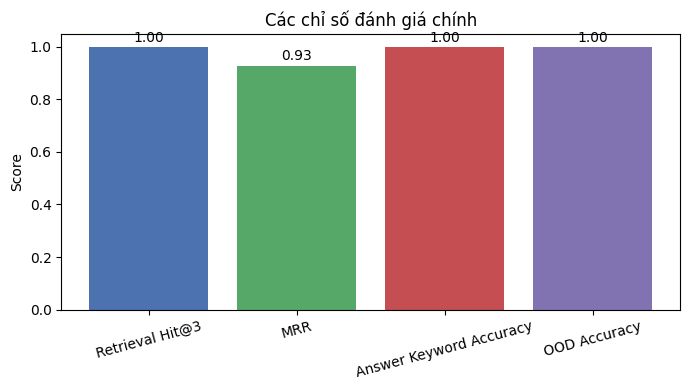

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
scores = ["Retrieval Hit@3", "MRR", "Answer Keyword Accuracy", "OOD Accuracy"]
values = [summary[m] for m in scores]
bars = ax.bar(scores, values)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Các chỉ số đánh giá chính")
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}", ha="center")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(REPORT_DIR / "core_metrics.png", dpi=150)
plt.show()

### 5.2 Thời gian phản hồi theo từng câu hỏi

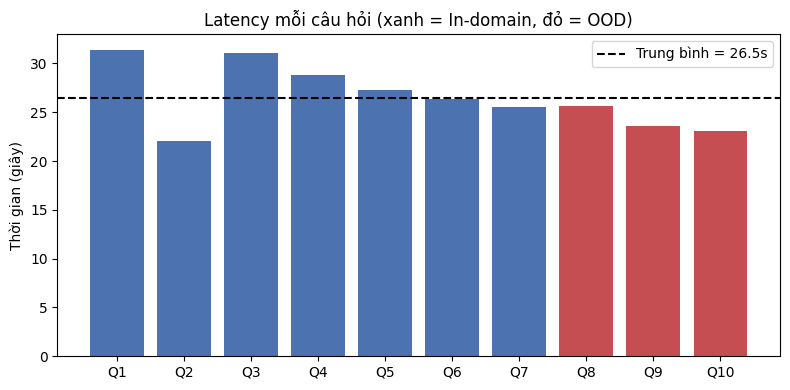

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4C72B0" if t == "In-domain" else "#C44E52" for t in df["type"]]
ax.bar(range(len(df)), df["time_s"], color=colors)
ax.axhline(summary["Mean Latency (s)"], color="black", linestyle="--", label=f"Trung bình = {summary['Mean Latency (s)']:.1f}s")
ax.set_xticks(range(len(df)))
ax.set_xticklabels([f"Q{i+1}" for i in range(len(df))])
ax.set_ylabel("Thời gian (giây)")
ax.set_title("Latency mỗi câu hỏi (xanh = In-domain, đỏ = OOD)")
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "latency.png", dpi=150)
plt.show()

### 5.3 Kết quả Pass/Fail theo từng câu (In-domain vs OOD)

In [9]:
df["passed"] = False

mask_in = df["type"] == "In-domain"
mask_ood = df["type"] == "OOD"

df.loc[mask_in, "passed"] = (
    df.loc[mask_in, "retrieval_ok"].fillna(False).astype(bool)
    & df.loc[mask_in, "answer_ok"].fillna(False).astype(bool)
)

df.loc[mask_ood, "passed"] = (
    df.loc[mask_ood, "ood_correct"].fillna(False).astype(bool)
)

pass_counts = df.groupby("type")["passed"].value_counts().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(6, 4))
pass_counts.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Số câu Pass/Fail theo nhóm")
ax.set_ylabel("Số câu hỏi")
ax.set_xlabel("")
ax.legend(["Fail", "Pass"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(REPORT_DIR / "pass_fail.png", dpi=150)
plt.show()


KeyError: 'ood_correct'

## 6. Lưu kết quả

In [ ]:
summary_df.to_csv(REPORT_DIR / "evaluation_summary.csv", index=False, encoding="utf-8-sig")
df.to_csv(REPORT_DIR / "evaluation_details.csv", index=False, encoding="utf-8-sig")

with open(REPORT_DIR / "evaluation_summary.json", "w", encoding="utf-8") as f:
    json.dump({k: float(v) for k, v in summary.items()}, f, ensure_ascii=False, indent=2)

print("Đã lưu kết quả vào", REPORT_DIR)